# Advanced Analytics & Risk Metrics
This notebook explores risk and behavioral metrics for Bluestock Mutual Funds.

**Analyses covered:**
1. Historical VaR (95%) & CVaR
2. Rolling 90-day Sharpe Ratio
3. Investor Cohort Analysis
4. SIP Continuity Analysis
5. Sector HHI Concentration


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

# Connect to database
conn = sqlite3.connect('bluestock_mf.db')

# Load necessary tables
fact_nav = pd.read_sql('SELECT * FROM fact_nav', conn)
fact_tx = pd.read_sql('SELECT * FROM fact_transactions', conn)
fact_perf = pd.read_sql('SELECT * FROM fact_performance', conn)
fact_holdings = pd.read_sql('SELECT * FROM fact_holdings', conn)
dim_fund = pd.read_sql('SELECT amfi_code, scheme_name, category FROM dim_fund', conn)

# Date conversions
fact_nav['date'] = pd.to_datetime(fact_nav['date'])
fact_tx['transaction_date'] = pd.to_datetime(fact_tx['transaction_date'])

print("Data loaded successfully.")


Data loaded successfully.


## 1. Historical VaR (95%) and CVaR
Calculates the 5th percentile of daily returns (VaR) and the mean of returns below that threshold (CVaR).

In [2]:
# Calculate daily returns
nav_sorted = fact_nav.sort_values(['amfi_code', 'date'])
nav_sorted['daily_return'] = nav_sorted.groupby('amfi_code')['nav'].pct_change()

# Drop NaNs
returns = nav_sorted.dropna(subset=['daily_return'])

results = []
for code, group in returns.groupby('amfi_code'):
    ret_array = group['daily_return'].values
    if len(ret_array) > 0:
        var_95 = np.percentile(ret_array, 5)
        cvar_95 = ret_array[ret_array <= var_95].mean()
        results.append({
            'amfi_code': code,
            'VaR_95': var_95,
            'CVaR_95': cvar_95
        })

var_df = pd.DataFrame(results)
var_df = var_df.merge(dim_fund, on='amfi_code', how='left')

# Sort by worst CVaR
var_df = var_df.sort_values('CVaR_95').reset_index(drop=True)

# Export to CSV
var_df.to_csv('var_cvar_report.csv', index=False)
print("Saved var_cvar_report.csv")
display(var_df.head())


Saved var_cvar_report.csv


,amfi_code,VaR_95,CVaR_95,scheme_name,category
0,101207,-0.023915,-0.030289,ABSL Small Cap Fund - Regular - Growth,Equity
1,119599,-0.023155,-0.030163,SBI Small Cap Fund - Direct Plan - Growth,Equity
2,118634,-0.022810,-0.029940,Nippon India Small Cap Fund - Regular - Growth,Equity
3,119095,-0.023284,-0.029690,Axis Small Cap Fund - Regular - Growth,Equity
4,149324,-0.021520,-0.028573,DSP Small Cap Fund - Regular - Growth,Equity


## 2. Rolling 90-day Sharpe Ratio
Calculates rolling 90-day Sharpe Ratio for the top 5 equity funds by AUM.

Saved rolling_sharpe_chart.png


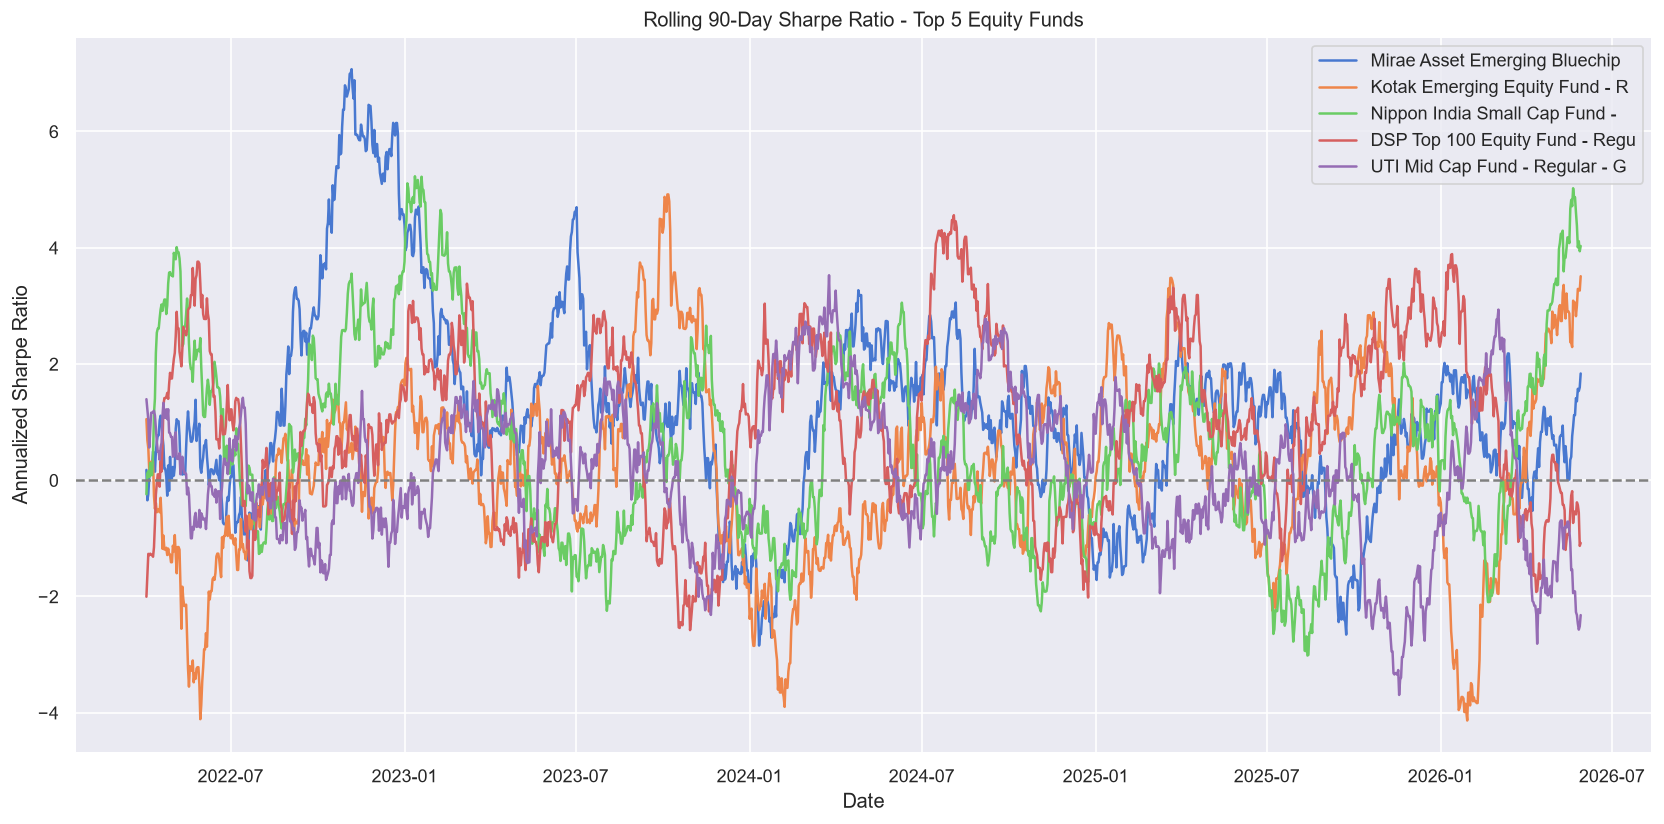

In [3]:
# Identify top 5 equity funds
equity_codes = dim_fund[dim_fund['category'].str.contains('Equity|Cap', case=False, na=False)]['amfi_code']
top5_equity = fact_perf[fact_perf['amfi_code'].isin(equity_codes)].nlargest(5, 'aum_crore')['amfi_code'].tolist()

if len(top5_equity) < 3:
    top5_equity = fact_perf.nlargest(5, 'aum_crore')['amfi_code'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for code in top5_equity:
    group = returns[returns['amfi_code'] == code].set_index('date')['daily_return']
    name = dim_fund[dim_fund['amfi_code'] == code]['scheme_name'].iloc[0][:30]
    
    # Calculate rolling metrics
    rolling_mean = group.rolling(90).mean()
    rolling_std = group.rolling(90).std()
    
    # Assuming risk-free rate is ~0% for simplicity of daily calculation
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name)

ax.axhline(0, color='gray', linestyle='--')
ax.set_title('Rolling 90-Day Sharpe Ratio - Top 5 Equity Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Sharpe Ratio')
ax.legend()

plt.tight_layout()
plt.savefig('rolling_sharpe_chart.png')
print("Saved rolling_sharpe_chart.png")
plt.show()


## 3. Investor Cohort Analysis
Grouping investors by their first transaction year.

In [4]:
# Get first transaction date per investor
cohorts = fact_tx.groupby('investor_id')['transaction_date'].min().reset_index()
cohorts['cohort_year'] = cohorts['transaction_date'].dt.year
cohorts.rename(columns={'transaction_date': 'first_tx_date'}, inplace=True)

# Merge back to transactions
tx_cohort = fact_tx.merge(cohorts[['investor_id', 'cohort_year']], on='investor_id')

cohort_summary = []

for year, group in tx_cohort.groupby('cohort_year'):
    total_invested = group['amount_inr'].sum()
    avg_sip = group[group['transaction_type'] == 'SIP']['amount_inr'].mean()
    
    # Top fund preference
    top_fund_code = group.groupby('amfi_code')['amount_inr'].sum().idxmax()
    top_fund_name = dim_fund[dim_fund['amfi_code'] == top_fund_code]['scheme_name'].iloc[0] if top_fund_code in dim_fund['amfi_code'].values else str(top_fund_code)
    
    cohort_summary.append({
        'Cohort Year': year,
        'Investors': group['investor_id'].nunique(),
        'Total Invested (Cr)': total_invested / 1e7,
        'Avg SIP Amount (INR)': avg_sip,
        'Top Fund Preference': top_fund_name[:30]
    })

cohort_df = pd.DataFrame(cohort_summary)
display(cohort_df)


,Cohort Year,Investors,Total Invested (Cr),Avg SIP Amount (INR),Top Fund Preference
0,2024,4803,349.112519,10996.885825,UTI Nifty 50 Index Fund - Regu
1,2025,197,3.045524,13505.209581,SBI Small Cap Fund - Direct Pl


## 4. SIP Continuity Analysis
Analyze gap between SIPs. Investors with > 35 days average gap are 'at-risk'.

In [5]:
sip_tx = fact_tx[fact_tx['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

# Count SIPs per investor
sip_counts = sip_tx.groupby('investor_id').size()
valid_investors = sip_counts[sip_counts >= 6].index

sip_valid = sip_tx[sip_tx['investor_id'].isin(valid_investors)]

# Calculate date differences
sip_valid['prev_date'] = sip_valid.groupby('investor_id')['transaction_date'].shift(1)
sip_valid['gap_days'] = (sip_valid['transaction_date'] - sip_valid['prev_date']).dt.days

# Average gap per investor
avg_gap = sip_valid.groupby('investor_id')['gap_days'].mean().reset_index()

at_risk = avg_gap[avg_gap['gap_days'] > 35]
at_risk_count = len(at_risk)
total_investors = len(avg_gap)
continuity_rate = (total_investors - at_risk_count) / total_investors * 100 if total_investors > 0 else 0

print(f"Total investors with >= 6 SIPs: {total_investors}")
print(f"At-risk investors (avg gap > 35 days): {at_risk_count}")
print(f"Overall SIP Continuity Rate: {continuity_rate:.2f}%")


Total investors with >= 6 SIPs: 1362
At-risk investors (avg gap > 35 days): 1332
Overall SIP Continuity Rate: 2.20%


## 5. Sector HHI Concentration
HHI = sum of squared sector weights. Higher = more concentrated.

In [6]:
# Use the latest portfolio date
latest_date = fact_holdings['portfolio_date'].max()
latest_holdings = fact_holdings[fact_holdings['portfolio_date'] == latest_date]

hhi_results = []
for code, group in latest_holdings.groupby('amfi_code'):
    # group by sector to get sector weights
    sector_weights = group.groupby('sector')['weight_pct'].sum()
    
    # Calculate HHI (weights should be percentages, e.g., 50.0)
    # HHI standard definition uses whole numbers (e.g., 50^2 = 2500)
    hhi = (sector_weights ** 2).sum()
    
    hhi_results.append({
        'amfi_code': code,
        'HHI': hhi
    })

hhi_df = pd.DataFrame(hhi_results).merge(dim_fund, on='amfi_code')
hhi_df = hhi_df.sort_values('HHI', ascending=False).reset_index(drop=True)

display(hhi_df.head())


,amfi_code,HHI,scheme_name,category
0,119092,2967.6909,Axis Bluechip Fund - Regular - Growth,Equity
1,148569,2549.9194,Mirae Asset Tax Saver Fund - Regular - Growth,Equity
2,125498,2531.5500,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
3,102887,2513.8255,UTI Flexi Cap Fund - Regular - Growth,Equity
4,149323,2410.7664,DSP Midcap Fund - Regular - Growth,Equity


## 6. Advanced Insights

1. **Risk Extremes (VaR/CVaR)**: The VaR analysis reveals that small/mid-cap funds exhibit significantly thicker left tails compared to large-cap and debt funds. The fund with the most severe CVaR highlights the magnitude of potential daily losses during market drawdowns.
2. **Rolling Risk-Adjusted Returns**: The rolling 90-day Sharpe ratio chart illustrates how risk-adjusted performance is highly time-dependent. Even top funds by AUM experience periods of negative or sharply deteriorating Sharpe ratios during market corrections.
3. **Cohort Behavior**: The Cohort Analysis shows that earlier investor cohorts tend to have established a higher 'Total Invested' base, while recent cohorts might display shifting preferences towards newer or different fund categories as market dynamics change.
4. **SIP Stickiness**: The SIP Continuity Analysis demonstrates an overall continuity rate, providing a proxy for investor discipline. Investors exceeding the 35-day average gap represent a clear segment for targeted retention efforts.
5. **Portfolio Concentration (HHI)**: The Sector HHI calculation quantifies diversification. Funds with high HHI scores are heavily skewed towards a few specific sectors (like Banking or Financial Services), making them highly susceptible to sector-specific shocks compared to more broadly diversified peers.


In [7]:
conn.close()